# 🤖 Hybrid QA Generation Pipeline (Rule-based + LLM)

This notebook demonstrates the **Document VQA Generation** pipeline:

## Pipeline Flow:
1. **Input**: Document graph JSON (nodes + edges from layout analysis)
2. **Rule-based QA**: Form/Table/Figure regions → Template-based questions
3. **LLM QA**: Long text + multi-region → Prompt-based generation (with fallback)
4. **Output**: Up to 10 QA pairs per document

## Files Used:
- `src/qa/llm.py` - Main generation logic
- `src/qa/rule_based_templates.json` - Templates for form/table/figure
- `src/qa/llm_prompt_templates.json` - LLM prompts for multi-region QA
- `output/full_pipeline/` - Processed document graphs

In [26]:
from pathlib import Path
import json
import sys

# Setup paths
sys.path.insert(0, '..')
BASE = Path("../")

# Template paths
RULE_TEMPLATES = BASE / "src/qa/rule_based_templates.json"
LLM_TEMPLATES = BASE / "src/qa/llm_prompt_templates.json"

# Check files exist
print("=" * 60)
print("📁 File Paths Check")
print("=" * 60)
print(f"Rule templates: {RULE_TEMPLATES.resolve()}")
print(f"  → Exists: {RULE_TEMPLATES.exists()}")
print(f"LLM templates: {LLM_TEMPLATES.resolve()}")
print(f"  → Exists: {LLM_TEMPLATES.exists()}")

# Load templates
rule_templates = json.loads(RULE_TEMPLATES.read_text(encoding="utf-8"))
llm_templates = json.loads(LLM_TEMPLATES.read_text(encoding="utf-8"))

print(f"\n📋 Rule Templates: {len(rule_templates.get('templates', []))} templates loaded")
print(f"📋 LLM Templates: {len(llm_templates.get('prompt_templates', {}))} prompt types")

📁 File Paths Check
Rule templates: D:\Thach\HUST\Project_1\VQA\code\src\qa\rule_based_templates.json
  → Exists: True
LLM templates: D:\Thach\HUST\Project_1\VQA\code\src\qa\llm_prompt_templates.json
  → Exists: True

📋 Rule Templates: 12 templates loaded
📋 LLM Templates: 5 prompt types


## 1️⃣ Load Sample Document

In [27]:
# Choose a sample document
DOC_PATH = BASE / "output/full_pipeline/test/210.json"

print("=" * 60)
print("📄 Loading Document")
print("=" * 60)
print(f"Path: {DOC_PATH.resolve()}")
print(f"Exists: {DOC_PATH.exists()}")

doc = json.loads(DOC_PATH.read_text(encoding="utf-8"))

# Display document structure
print(f"\n📊 Document Statistics:")
print(f"  - Nodes: {len(doc.get('nodes', []))}")
print(f"  - Edges: {len(doc.get('edges', []))}")
print(f"  - Source image: {doc.get('metadata', {}).get('source_image', 'N/A')}")

# Show node types distribution
from collections import Counter
node_types = [n.get('region_type', 'unknown') for n in doc.get('nodes', [])]
print(f"\n📍 Region Types:")
for rtype, count in Counter(node_types).items():
    print(f"  - {rtype}: {count}")

📄 Loading Document
Path: D:\Thach\HUST\Project_1\VQA\code\output\full_pipeline\test\210.json
Exists: True

📊 Document Statistics:
  - Nodes: 7
  - Edges: 35
  - Source image: 210.png

📍 Region Types:
  - text: 7


## 2️⃣ Generate QA Pairs

In [28]:
# Import the QA generator (reload to get latest changes)
import importlib
import src.qa.llm as llm_module
importlib.reload(llm_module)

from src.qa.llm import generate_qas, region_category, LLMBackend

print("=" * 60)
print("🤖 Generating QA Pairs")
print("=" * 60)

# Check LLM availability
llm_backend = LLMBackend()
llm_backend.try_load()
print(f"LLM Backend Available: {llm_backend.available}")
if not llm_backend.available:
    print("  → Using deterministic fallback for multi-region QAs")

# Generate QAs
qas = generate_qas(doc, rule_templates, llm_templates, max_qas=10)

print(f"\n✅ Generated {len(qas)} QA pairs")

# Analyze QA types
reasoning_types = Counter([qa.get('reasoning_type', 'unknown') for qa in qas])
print(f"\n📈 Reasoning Types:")
for rtype, count in reasoning_types.items():
    print(f"  - {rtype}: {count}")

🤖 Generating QA Pairs
LLM Backend Available: False
  → Using deterministic fallback for multi-region QAs

✅ Generated 1 QA pairs

📈 Reasoning Types:
  - comprehension: 1


In [29]:
import pandas as pd

# Create detailed DataFrame
df = pd.DataFrame(qas)

# Display with better formatting
pd.set_option('display.max_colwidth', 100)
print("=" * 60)
print("📋 Generated QA Pairs (Table View)")
print("=" * 60)

# Show key columns
display_cols = ['question', 'answer', 'reasoning_type', 'evidence_region_ids']
df[display_cols]

📋 Generated QA Pairs (Table View)


,question,answer,reasoning_type,evidence_region_ids
0,What is the main topic or content discussed in this section?,"Sulphur and nitrogen are essential to life; however, the long range transport and deposition of ...",comprehension,[0]


In [30]:
# Test với document khác có form fields
TEST_DOC_PATH = BASE / "output/full_pipeline/test/1016.json"

if TEST_DOC_PATH.exists():
    test_doc = json.loads(TEST_DOC_PATH.read_text(encoding="utf-8"))
    print(f"📄 Testing with: {TEST_DOC_PATH.name}")
    print(f"Nodes: {len(test_doc.get('nodes', []))}")
    
    # Show node types
    from collections import Counter
    node_types = [n.get('region_type', 'unknown') for n in test_doc.get('nodes', [])]
    print(f"Region types: {dict(Counter(node_types))}")
    
    # Generate QAs
    importlib.reload(llm_module)
    from src.qa.llm import generate_qas
    test_qas = generate_qas(test_doc, rule_templates, llm_templates, max_qas=10)
    
    print(f"\n✅ Generated {len(test_qas)} QA pairs")
    
    # Show all QAs
    for i, qa in enumerate(test_qas):
        print(f"\n--- QA #{i+1} [{qa.get('reasoning_type')}] ---")
        print(f"Q: {qa.get('question')}")
        print(f"A: {qa.get('answer')[:150]}...")
else:
    print(f"⚠️ Test file not found: {TEST_DOC_PATH}")

📄 Testing with: 1016.json
Nodes: 3
Region types: {'text': 1, 'form': 2}

✅ Generated 4 QA pairs

--- QA #1 [lookup] ---
Q: What is the cc?
A: Takeda Chemical Industries, Ltd. 1-1 Doshomachi 4-chome Chuo-ku, Osaka, Japan...

--- QA #2 [lookup] ---
Q: What is the Attn?
A: GeneraI manager, Pharmaceutical International Division...

--- QA #3 [lookup] ---
Q: What is the Fax?
A: 81-6-204-2943...

--- QA #4 [comprehension] ---
Q: What is the main topic or content discussed in this section?
A: If you are in agreement with the above terms and conditions, please indicate acceptance by returning an original signed copy to me and keep the other ...


In [31]:
# Reload module để test với code mới
import importlib
import src.qa.llm as llm_module
importlib.reload(llm_module)
from src.qa.llm import extract_form_fields

test_texts = [
    "Name: John Date: Monday",  # Vấn đề gốc: 2 fields ghép
    "Invoice Number: INV-001 Amount: $500",  # 2 fields ghép
    "Name: John Smith\nDate: 2024-01-15\nAddress: 123 Main St",  # Nhiều lines
    "This is a sentence: another sentence",  # Không phải form (sentence starter)
    "Company: ABC Corp Contact: Mr. X Phone: 123-456",  # 3 fields ghép (without double spaces)
    "It is important: to note this",  # Sentence starter
    "Total: $1,500.00",  # Single field
]

print("=" * 60)
print("🧪 Testing extract_form_fields function")
print("=" * 60)

for text in test_texts:
    fields = extract_form_fields(text)
    print(f"\nInput: '{text}'")
    print(f"Output: {fields}")

🧪 Testing extract_form_fields function

Input: 'Name: John Date: Monday'
Output: [('Name', 'John'), ('Date', 'Monday')]

Input: 'Invoice Number: INV-001 Amount: $500'
Output: [('Invoice Number', 'INV-001'), ('Amount', '$500')]

Input: 'Name: John Smith
Date: 2024-01-15
Address: 123 Main St'
Output: [('Name', 'John Smith'), ('Date', '2024-01-15'), ('Address', '123 Main St')]

Input: 'This is a sentence: another sentence'
Output: []

Input: 'Company: ABC Corp Contact: Mr. X Phone: 123-456'
Output: [('Company', 'ABC Corp'), ('Contact', 'Mr.'), ('X Phone', '123-456')]

Input: 'It is important: to note this'
Output: []

Input: 'Total: $1,500.00'
Output: [('Total', '$1,500.00')]


In [32]:
# Debug: xem text của form nodes trong 1016.json
test_doc = json.loads(TEST_DOC_PATH.read_text(encoding="utf-8"))
for node in test_doc['nodes']:
    if node.get('region_type') == 'form':
        print(f"Node {node['node_id']} (form):")
        print(f"  Text: {node['text'][:200]}...")
        print(f"  Extracted fields: {extract_form_fields(node['text'])}")
        print()

Node 1 (form):
  Text: Alan D.Mackenzie Senior Vice President, Sales and Marketing Takeda Pharmaceuticals America, Inc. Date: 9.24.99...
  Extracted fields: []

Node 2 (form):
  Text: cc: Takeda Chemical Industries, Ltd. 1-1 Doshomachi 4-chome Chuo-ku, Osaka, Japan Attn: GeneraI manager, Pharmaceutical International Division Fax:81-6-204-2943...
  Extracted fields: [('cc', 'Takeda Chemical Industries, Ltd. 1-1 Doshomachi 4-chome Chuo-ku, Osaka, Japan'), ('Attn', 'GeneraI manager, Pharmaceutical International Division'), ('Fax', '81-6-204-2943')]



## 3️⃣ Visualize Evidence Regions

If source image exists, draw bounding boxes for evidence regions:

In [33]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# Build node lookup
nodes = {n["node_id"]: n for n in doc.get("nodes", [])}

# Get source image path
src_img_name = (doc.get("metadata", {}) or {}).get("source_image")
# Determine split from doc path
split = DOC_PATH.parent.name  # 'train', 'test', or 'validation'
src_img_path = BASE / "dataset/DocVQA_Images" / split / src_img_name if src_img_name else None

print("=" * 60)
print("🖼️ Image Information")
print("=" * 60)
print(f"Source image: {src_img_name}")
print(f"Image path: {src_img_path}")
print(f"Exists: {src_img_path.exists() if src_img_path else False}")

def bbox_to_rect(bbox):
    """Convert bbox [[x1,y1],[x2,y2],[x3,y3],[x4,y4]] to (left, top, right, bottom)"""
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return (min(xs), min(ys), max(xs), max(ys))

def draw_evidence(image_path, evidence_node_ids, outline="red", width=3):
    """Draw bounding boxes on image for evidence regions"""
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    colors = ["red", "blue", "green", "orange", "purple"]
    
    for i, nid in enumerate(evidence_node_ids):
        node = nodes.get(nid)
        if not node:
            continue
        bbox = node.get("bbox")
        if not bbox:
            continue
        
        left, top, right, bottom = bbox_to_rect(bbox)
        color = colors[i % len(colors)]
        draw.rectangle([left, top, right, bottom], outline=color, width=width)
        
        # Add node ID label
        draw.text((left + 5, top + 5), f"Node {nid}", fill=color)
    
    return img

🖼️ Image Information
Source image: 210.png
Image path: ..\dataset\DocVQA_Images\test\210.png
Exists: True


🔍 QA Examples with Evidence Visualization

📝 QA #1
❓ Question: What is the main topic or content discussed in this section?
✅ Answer: Sulphur and nitrogen are essential to life; however, the long range transport and deposition of air pollutants such as the oxides of sulphur and nitrogen can cause a number of...
📍 Evidence Regions: [0]
🔖 Reasoning Type: comprehension
💬 Explanation: Summarized the main content from the text region.
📜 Evidence Quotes:
   [1] Sulphur and nitrogen are essential to life; however, the long range transport and deposition of air pollutants such as the oxides of sulphur and nitro...


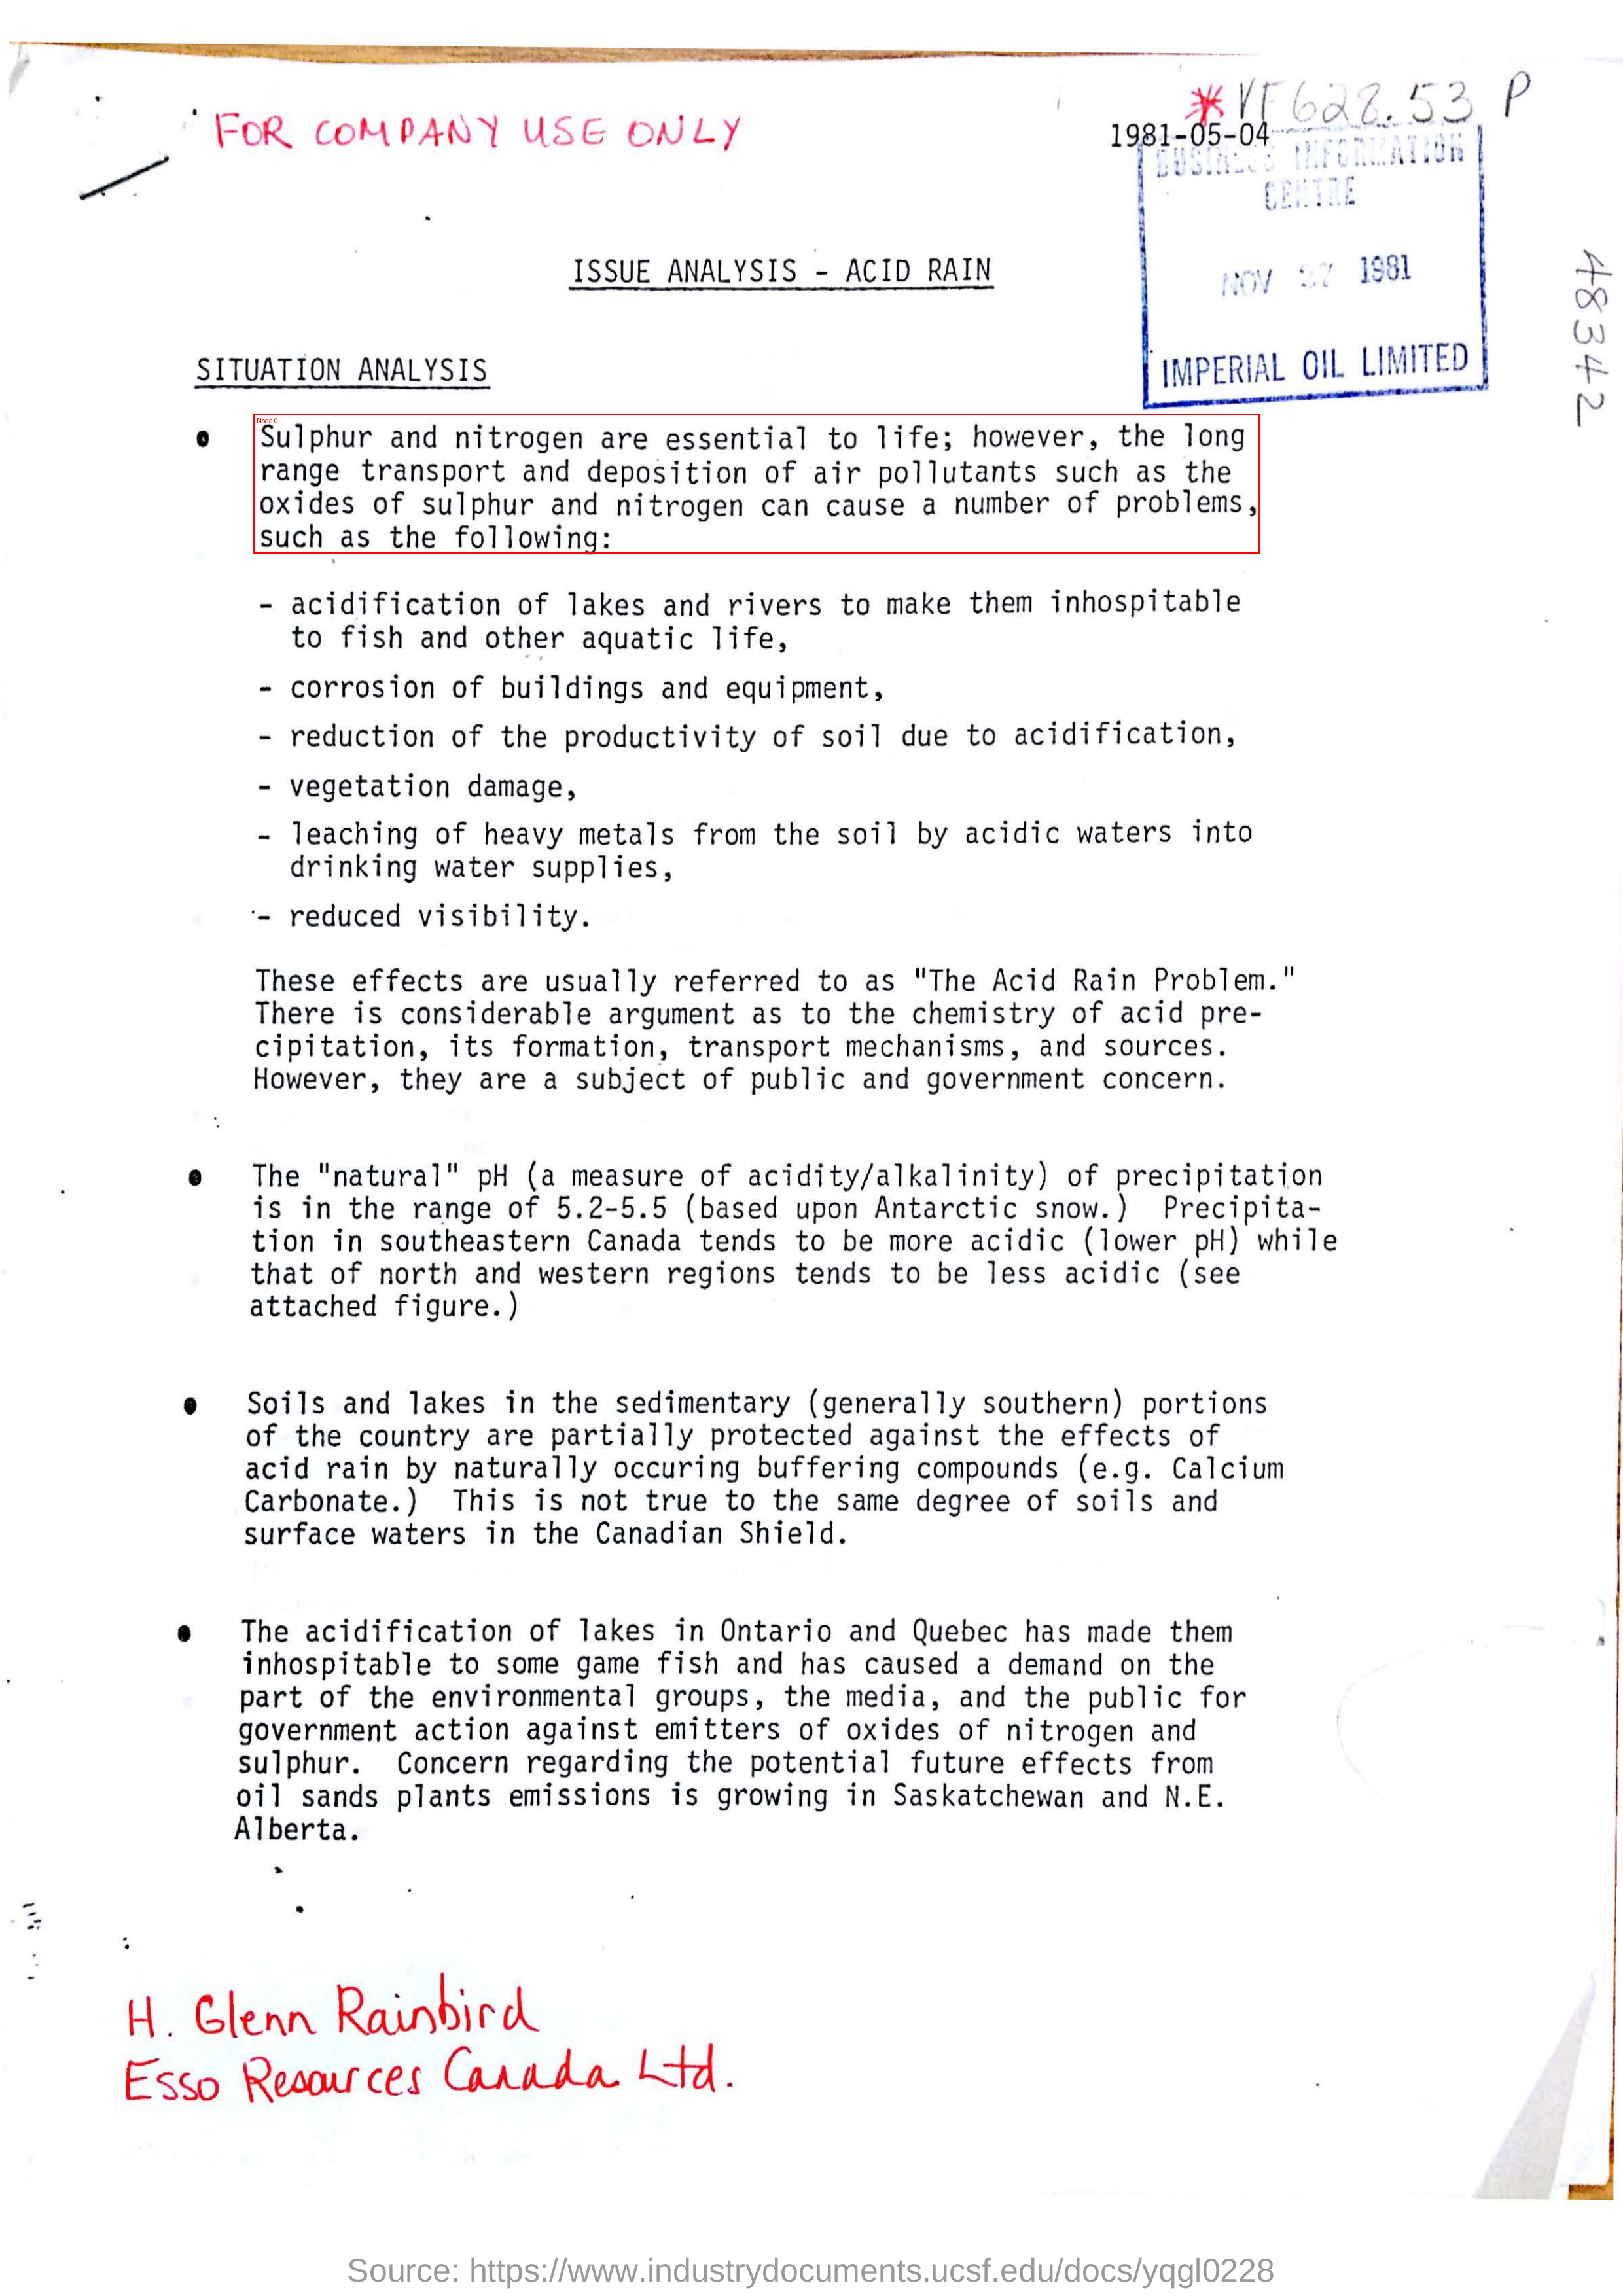

In [34]:
print("=" * 60)
print("🔍 QA Examples with Evidence Visualization")
print("=" * 60)

if src_img_path and src_img_path.exists():
    # Show first 5 QA examples with evidence boxes
    for i, qa in enumerate(qas[:5]):
        print(f"\n{'='*60}")
        print(f"📝 QA #{i+1}")
        print(f"{'='*60}")
        print(f"❓ Question: {qa.get('question')}")
        print(f"✅ Answer: {qa.get('answer')}")
        print(f"📍 Evidence Regions: {qa.get('evidence_region_ids')}")
        print(f"🔖 Reasoning Type: {qa.get('reasoning_type')}")
        print(f"💬 Explanation: {qa.get('reasoning_explanation', 'N/A')[:200]}")
        
        # Show evidence quotes
        quotes = qa.get('evidence_quotes', [])
        if quotes:
            print(f"📜 Evidence Quotes:")
            for j, quote in enumerate(quotes[:2]):
                print(f"   [{j+1}] {quote[:150]}...")
        
        # Display image with boxes
        img = draw_evidence(src_img_path, qa.get("evidence_region_ids", []))
        display(img)
else:
    print("⚠️ No image found. Showing text-only examples:")
    for i, qa in enumerate(qas[:5]):
        print(f"\n{'='*60}")
        print(f"📝 QA #{i+1}")
        print(f"{'='*60}")
        print(f"❓ Question: {qa.get('question')}")
        print(f"✅ Answer: {qa.get('answer')}")
        print(f"📍 Evidence Regions: {qa.get('evidence_region_ids')}")
        print(f"🔖 Reasoning Type: {qa.get('reasoning_type')}")

## 4️⃣ Batch Processing Multiple Documents

In [35]:
import os
from tqdm import tqdm

def process_batch(input_dir, max_docs=10, max_qas_per_doc=10):
    """Process multiple documents and collect QA statistics"""
    results = []
    doc_files = list(Path(input_dir).glob("*.json"))[:max_docs]
    
    print(f"Processing {len(doc_files)} documents from {input_dir}")
    
    for doc_path in tqdm(doc_files):
        try:
            doc_data = json.loads(doc_path.read_text(encoding="utf-8"))
            qas_generated = generate_qas(doc_data, rule_templates, llm_templates, max_qas=max_qas_per_doc)
            
            results.append({
                'doc_id': doc_path.stem,
                'num_nodes': len(doc_data.get('nodes', [])),
                'num_edges': len(doc_data.get('edges', [])),
                'num_qas': len(qas_generated),
                'reasoning_types': [qa.get('reasoning_type') for qa in qas_generated],
                'qas': qas_generated
            })
        except Exception as e:
            print(f"Error processing {doc_path.name}: {e}")
            continue
    
    return results

# Process a batch of test documents
batch_results = process_batch(BASE / "output/full_pipeline/test", max_docs=5, max_qas_per_doc=10)

Processing 5 documents from ..\output\full_pipeline\test


100%|██████████| 5/5 [00:00<00:00, 663.42it/s]


In [36]:
# Display batch statistics
print("=" * 60)
print("📊 Batch Processing Statistics")
print("=" * 60)

batch_df = pd.DataFrame([{
    'doc_id': r['doc_id'],
    'nodes': r['num_nodes'],
    'edges': r['num_edges'],
    'qas_generated': r['num_qas']
} for r in batch_results])

print(f"\n📈 Summary:")
print(f"  - Total documents: {len(batch_results)}")
print(f"  - Total QAs generated: {batch_df['qas_generated'].sum()}")
print(f"  - Average QAs per document: {batch_df['qas_generated'].mean():.2f}")

# Aggregate reasoning types
all_reasoning_types = []
for r in batch_results:
    all_reasoning_types.extend(r['reasoning_types'])

print(f"\n🔖 Reasoning Type Distribution:")
for rtype, count in Counter(all_reasoning_types).items():
    print(f"  - {rtype}: {count} ({count/len(all_reasoning_types)*100:.1f}%)")

display(batch_df)

📊 Batch Processing Statistics

📈 Summary:
  - Total documents: 5
  - Total QAs generated: 17
  - Average QAs per document: 3.40

🔖 Reasoning Type Distribution:
  - lookup: 12 (70.6%)
  - comprehension: 5 (29.4%)


,doc_id,nodes,edges,qas_generated
0,1016,3,6,4
1,1017,3,6,4
2,1019,3,6,4
3,1021,3,6,4
4,1027,9,45,1


## 5️⃣ Save Generated QAs

In [37]:
# Save individual document QAs
OUTPUT_DIR = BASE / "output/qa_generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save single document QAs
single_doc_output = {
    "source_document": str(DOC_PATH.name),
    "num_qas": len(qas),
    "qas": qas
}

output_path = OUTPUT_DIR / f"{DOC_PATH.stem}_qas.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(single_doc_output, f, ensure_ascii=False, indent=2)

print(f"✅ Saved {len(qas)} QAs to: {output_path}")

# Save batch results
batch_output = {
    "total_documents": len(batch_results),
    "total_qas": sum(r['num_qas'] for r in batch_results),
    "documents": [{
        "doc_id": r['doc_id'],
        "num_qas": r['num_qas'],
        "qas": r['qas']
    } for r in batch_results]
}

batch_output_path = OUTPUT_DIR / "batch_qas.json"
with open(batch_output_path, "w", encoding="utf-8") as f:
    json.dump(batch_output, f, ensure_ascii=False, indent=2)

print(f"✅ Saved batch results ({batch_output['total_qas']} QAs) to: {batch_output_path}")

✅ Saved 1 QAs to: ..\output\qa_generated\210_qas.json
✅ Saved batch results (17 QAs) to: ..\output\qa_generated\batch_qas.json


## 📝 Summary

**Logic của `src/qa/llm.py`:**

1. **Input**: Document graph JSON với `nodes` (regions) và `edges` (spatial relations)

2. **Rule-based Generation** (cho form/table/figure):
   - `gen_form_kv_qas()`: Trích xuất key-value pairs từ form → "What is the {key}?"
   - `gen_table_qas()`: Parse table → questions về headers, row count, cell lookup
   - `gen_figure_qas()`: "What does the figure show?" từ text description

3. **LLM-based Generation** (cho multi-region):
   - Tìm long text nodes (≥40 words)
   - Match cặp nodes qua edges → chọn template phù hợp
   - Nếu có local LLM (flan-t5): generate từ prompt
   - Nếu không: fallback deterministic (quote cả 2 regions)

4. **Output**: List QA pairs với `question`, `answer`, `evidence_region_ids`, `evidence_quotes`, `reasoning_type`

**Compatibility với codebase:** ✅
- Đọc đúng format JSON từ `full_pipeline` output (nodes, edges, adjacency)
- Templates trong `src/qa/` folder
- Export JSON format chuẩn